## **Laptop Price Prediction**



### **About Dataset**
The Uncleaned Laptop Price dataset is a collection of laptop product listings scraped from an online e-commerce website. The dataset includes information about various laptop models, such as their brand, screen size, processor, memory, storage capacity, operating system, and price. However, the dataset is uncleaned, meaning that it contains missing values, inconsistent formatting, and other errors that need to be addressed before the data can be used for analysis or modeling.

The dataset contains both categorical and numerical variables, with the majority of variables being categorical, including brand, model name, screen resolution, processor type, and operating system. Some numerical variables include screen size, memory, and storage capacity. The target variable in the dataset is the price, which is a continuous variable.

The dataset contains over 1,300 laptop listings, making it a reasonably sized dataset for analysis and modeling. The dataset may be useful for machine learning projects related to predicting the price of a laptop based on its specifications. However, before using the dataset, it would be necessary to clean and preprocess the data to address the inconsistencies and missing values.

**Data collected:** 3 years ago

- **Import Libraries**

### **About Author**
**Name:** Muhammad Nawawz\
**Facebook:** https://web.facebook.com/profile.php?id=61590324605378 \
**Email:** muhammadnawazmnkhan@gmail.com\
**Github:** https://github.com/MuhammadNawaz1-a \
**Streamlit:** https://laptopspricepredictionmn.streamlit.app/

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

- **Load Dataset**

In [2]:
df = pd.read_csv("../laptop_data.txt")

- **Assessing Data**

In [3]:
df.shape

(1303, 12)

In [4]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [5]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   TypeName          1303 non-null   str    
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   str    
 4   Cpu               1303 non-null   str    
 5   Ram               1303 non-null   str    
 6   Memory            1303 non-null   str    
 7   Gpu               1303 non-null   str    
 8   OpSys             1303 non-null   str    
 9   Weight            1303 non-null   str    
 10  Price             1303 non-null   float64
dtypes: float64(2), str(9)
memory usage: 250.8 KB


In [7]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(29)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.describe(include='all')

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
count,1274,1274,1274.000000,1274,1274,1274,1274,1274,1274,1274,1274.000000
unique,19,6,NaN,40,118,9,39,110,9,179,NaN
top,Dell,Notebook,NaN,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,NaN
freq,291,706,NaN,505,190,613,412,279,1047,116,NaN
mean,NaN,NaN,15.022449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60503.185074
std,NaN,NaN,1.429940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37333.222977
min,NaN,NaN,10.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9270.720000
25%,NaN,NaN,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32495.605200
50%,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52693.920000
75%,NaN,NaN,15.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79773.480000


In [11]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='str')

In [12]:
df.nunique()

Company              19
TypeName              6
Inches               18
ScreenResolution     40
Cpu                 118
Ram                   9
Memory               39
Gpu                 110
OpSys                 9
Weight              179
Price               791
dtype: int64

- **Data Cleaning**

In [13]:
df["ScreenResolution"].unique()

<ArrowStringArray>
[           'IPS Panel Retina Display 2560x1600',
                                      '1440x900',
                             'Full HD 1920x1080',
            'IPS Panel Retina Display 2880x1800',
                                      '1366x768',
                   'IPS Panel Full HD 1920x1080',
            'IPS Panel Retina Display 2304x1440',
     'IPS Panel Full HD / Touchscreen 1920x1080',
               'Full HD / Touchscreen 1920x1080',
              'Touchscreen / Quad HD+ 3200x1800',
               'IPS Panel Touchscreen 1920x1200',
                         'Touchscreen 2256x1504',
              'Quad HD+ / Touchscreen 3200x1800',
                            'IPS Panel 1366x768',
 'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
                   'IPS Panel Full HD 2160x1440',
           '4K Ultra HD / Touchscreen 3840x2160',
                         'Touchscreen 2560x1440',
                                      '1600x900',
               'IPS Panel 4K Ul

In [14]:
df["Touchscreen"] = df["ScreenResolution"].apply(lambda x: 1 if "Touchscreen" in str(x) else 0)
df["Ips"] = df["ScreenResolution"].apply(lambda x: 1 if "IPS" in str(x) else 0)
df["Screen_width"] = df["ScreenResolution"].str.extract(r"(\d+)x(\d+)")[0].astype(int)
df["Screen_height"] = df["ScreenResolution"].str.extract(r"(\d+)x(\d+)")[1].astype(int)
df["Ppi"] = (np.sqrt(df["Screen_width"] ** 2 + df["Screen_height"] ** 2) / df["Inches"]).round(2)

In [15]:
df["Cpu"].unique()

<ArrowStringArray>
[                'Intel Core i5 2.3GHz',
                 'Intel Core i5 1.8GHz',
           'Intel Core i5 7200U 2.5GHz',
                 'Intel Core i7 2.7GHz',
                 'Intel Core i5 3.1GHz',
              'AMD A9-Series 9420 3GHz',
                 'Intel Core i7 2.2GHz',
           'Intel Core i7 8550U 1.8GHz',
           'Intel Core i5 8250U 1.6GHz',
             'Intel Core i3 6006U 2GHz',
 ...
                  'Intel Core M 1.1GHz',
 'Intel Pentium Dual Core 4405Y 1.5GHz',
 'Intel Pentium Quad Core N3700 1.6GHz',
             'Intel Core M 6Y54 1.1GHz',
          'Intel Core i7 6500U 2.50GHz',
   'Intel Celeron Dual Core N3350 2GHz',
        'Samsung Cortex A72&A53 2.0GHz',
             'AMD E-Series 9000 2.2GHz',
             'Intel Core M 6Y30 0.9GHz',
            'AMD A9-Series 9410 2.9GHz']
Length: 118, dtype: str

In [16]:
df["Cpu_speed_GHz"] = df["Cpu"].str.split().str[-1].str.replace("GHz", "").astype(float)
df["Cpu_name"] = df["Cpu"].str.split().str[0:3].str.join(" ")
df["Cpu_gen"] = df["Cpu"].str.extract(r"i[3579]\s*(\d)\d{3}")[0].fillna(0)

In [17]:
df["Cpu_name"].unique()

array(['Intel Core i5', 'Intel Core i7', 'AMD A9-Series 9420',
       'Intel Core i3', 'Intel Core M', 'Intel Atom x5-Z8350',
       'AMD E-Series E2-9000e', 'Intel Atom x5-Z8300',
       'AMD E-Series E2-6110', 'AMD A6-Series 9220', 'Intel Celeron Dual',
       'AMD Ryzen 1700', 'Intel Pentium Quad', 'Intel Atom x5-Z8550',
       'AMD FX 9830P', 'AMD E-Series 6110', 'Intel Xeon E3-1505M',
       'AMD E-Series 9000e', 'AMD A10-Series A10-9620P',
       'AMD A6-Series A6-9220', 'AMD A10-Series 9600P',
       'AMD A8-Series 7410', 'AMD A12-Series 9720P', 'Intel Celeron Quad',
       'AMD Ryzen 1600', 'AMD A10-Series 9620P', 'AMD E-Series 7110',
       'AMD A9-Series A9-9420', 'Intel Xeon E3-1535M',
       'AMD E-Series E2-9000', 'AMD A6-Series 7310', 'Intel Atom Z8350',
       'Intel Pentium Dual', 'AMD A12-Series 9700P', 'AMD A4-Series 7210',
       'AMD FX 8800P', 'Intel Atom X5-Z8350', 'Samsung Cortex A72&A53',
       'AMD E-Series 9000', 'AMD A9-Series 9410'], dtype=object)

In [18]:
core_zero_mask = df["Cpu_name"].str.contains("Core i", na=False) & (df["Cpu_gen"] == 0)
df.loc[core_zero_mask, "Cpu_gen"] = 7

def process_cpu_name(text):
    text = str(text).strip()
    if text in ['Intel Core i7', 'Intel Core i5', 'Intel Core i3']:
        return text
    elif 'Intel' in text:
        return 'Other Intel Processor'
    elif 'AMD' in text:
        return 'AMD Processor'
    else:
        return 'Other Processor'

df['Cpu_brand'] = df['Cpu_name'].apply(process_cpu_name)

In [19]:
df["Memory"].unique()

<ArrowStringArray>
[                    '128GB SSD',           '128GB Flash Storage',
                     '256GB SSD',                     '512GB SSD',
                     '500GB HDD',           '256GB Flash Storage',
                       '1TB HDD',            '32GB Flash Storage',
          '128GB SSD +  1TB HDD',        '256GB SSD +  256GB SSD',
            '64GB Flash Storage',          '256GB SSD +  1TB HDD',
          '256GB SSD +  2TB HDD',                      '32GB SSD',
                       '2TB HDD',                      '64GB SSD',
                  '1.0TB Hybrid',          '512GB SSD +  1TB HDD',
                       '1TB SSD',        '256GB SSD +  500GB HDD',
          '128GB SSD +  2TB HDD',        '512GB SSD +  512GB SSD',
                      '16GB SSD',            '16GB Flash Storage',
        '512GB SSD +  256GB SSD',          '512GB SSD +  2TB HDD',
 '64GB Flash Storage +  1TB HDD',                     '180GB SSD',
            '1TB HDD +  1TB HDD',          

In [20]:
def get_storage_gb(text, drive_type):
    if drive_type not in str(text):
        return 0
    match = re.search(r"(\d+)(GB|TB)\s+" + drive_type, str(text))
    if match:
        size, unit = int(match.group(1)), match.group(2)
        return size * 1024 if unit == "TB" else size
    return 0

df["SSD_GB"] = df["Memory"].apply(lambda x: get_storage_gb(x, "SSD"))
df["HDD_GB"] = df["Memory"].apply(lambda x: get_storage_gb(x, "HDD"))
df["FlashStorage_GB"] = df["Memory"].apply(lambda x: get_storage_gb(x, "Flash Storage"))

In [21]:
df["Gpu"].unique()

<ArrowStringArray>
['Intel Iris Plus Graphics 640',       'Intel HD Graphics 6000',
        'Intel HD Graphics 620',           'AMD Radeon Pro 455',
 'Intel Iris Plus Graphics 650',                'AMD Radeon R5',
      'Intel Iris Pro Graphics',         'Nvidia GeForce MX150',
       'Intel UHD Graphics 620',        'Intel HD Graphics 520',
 ...
      'Nvidia GeForce GTX 980 ',           'AMD Radeon R5 M330',
           'AMD FirePro W4190M',           'AMD FirePro W6150M',
           'AMD Radeon R5 M315',          'Nvidia Quadro M500M',
           'AMD Radeon R7 M360',         'Nvidia Quadro M3000M',
          'Nvidia GeForce 960M',            'ARM Mali T860 MP4']
Length: 110, dtype: str

In [22]:
df["Gpu_Brand"] = df["Gpu"].str.split().str[0]

In [23]:
df["Ram"] = df["Ram"].str.replace("GB", "").astype(int)
df["Weight"] = df["Weight"].str.replace("kg", "").astype(float)

In [24]:
df["OpSys"].unique()

<ArrowStringArray>
[       'macOS',        'No OS',   'Windows 10',     'Mac OS X',
        'Linux',      'Android', 'Windows 10 S',    'Chrome OS',
    'Windows 7']
Length: 9, dtype: str

In [25]:
df["OpSys"] = df["OpSys"].replace("No OS", np.nan)
df["OpSys"] = df["OpSys"].replace({"Mac OS X": "macOS", "Windows 10 S": "Windows 10"})

In [26]:
df.isnull().sum()

Company              0
TypeName             0
Inches               0
ScreenResolution     0
Cpu                  0
Ram                  0
Memory               0
Gpu                  0
OpSys               66
Weight               0
Price                0
Touchscreen          0
Ips                  0
Screen_width         0
Screen_height        0
Ppi                  0
Cpu_speed_GHz        0
Cpu_name             0
Cpu_gen              0
Cpu_brand            0
SSD_GB               0
HDD_GB               0
FlashStorage_GB      0
Gpu_Brand            0
dtype: int64

In [27]:
df.dropna(inplace=True)

In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,Screen_height,Ppi,Cpu_speed_GHz,Cpu_name,Cpu_gen,Cpu_brand,SSD_GB,HDD_GB,FlashStorage_GB,Gpu_Brand
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,...,1600,226.98,2.3,Intel Core i5,7,Intel Core i5,128,0,0,Intel
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,...,900,127.68,1.8,Intel Core i5,7,Intel Core i5,0,0,128,Intel


In [30]:
df.shape

(1208, 24)

In [31]:
df.drop(columns=['Cpu_name', "ScreenResolution", "Cpu", "Gpu", "Memory", "Ppi", "FlashStorage_GB"], inplace=True)

In [32]:
df.shape

(1208, 17)

- **EDA(Exploratory Data Anlysis)**

In [33]:
df.describe()

,Inches,Ram,Weight,Price,Touchscreen,Ips,Screen_width,Screen_height,Cpu_speed_GHz,SSD_GB,HDD_GB
count,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000,1208.000000
mean,14.985596,8.554636,2.032376,62097.236189,0.155629,0.283940,1912.114238,1080.986755,2.308609,190.870861,406.754967
std,1.451009,5.170209,0.680998,37538.645785,0.362654,0.451095,500.139298,287.826020,0.505512,186.775108,523.215943
min,10.100000,2.000000,0.690000,9270.720000,0.000000,0.000000,1366.000000,768.000000,0.900000,0.000000,0.000000
25%,14.000000,4.000000,1.490000,34552.080000,0.000000,0.000000,1920.000000,1080.000000,2.000000,0.000000,0.000000
50%,15.600000,8.000000,2.020000,54265.413600,0.000000,0.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,80468.650800,0.000000,1.000000,1920.000000,1080.000000,2.700000,256.000000,1024.000000
max,18.400000,64.000000,4.700000,324954.720000,1.000000,1.000000,3840.000000,2160.000000,3.600000,1024.000000,2048.000000


In [34]:
df.corr(numeric_only=True)

,Inches,Ram,Weight,Price,Touchscreen,Ips,Screen_width,Screen_height,Cpu_speed_GHz,SSD_GB,HDD_GB
Inches,1.000000,0.256065,0.827863,0.089795,-0.357074,-0.103235,-0.058033,-0.083273,0.323619,-0.086978,0.532728
Ram,0.256065,1.000000,0.395911,0.738649,0.104161,0.191742,0.417846,0.408673,0.364542,0.599544,0.118375
Weight,0.827863,0.395911,1.000000,0.224582,-0.293093,0.021946,-0.027769,-0.049569,0.326046,-0.046724,0.519463
Price,0.089795,0.738649,0.224582,1.000000,0.175339,0.241442,0.545426,0.541013,0.430503,0.672690,-0.076847
Touchscreen,-0.357074,0.104161,-0.293093,0.175339,1.000000,0.139876,0.339173,0.346307,-0.099237,0.242335,-0.202154
Ips,-0.103235,0.191742,0.021946,0.241442,0.139876,1.000000,0.265765,0.274218,0.051109,0.205355,-0.078353
Screen_width,-0.058033,0.417846,-0.027769,0.545426,0.339173,0.265765,1.000000,0.993915,0.167135,0.522233,-0.109104
Screen_height,-0.083273,0.408673,-0.049569,0.541013,0.346307,0.274218,0.993915,1.000000,0.152467,0.512774,-0.121531
Cpu_speed_GHz,0.323619,0.364542,0.326046,0.430503,-0.099237,0.051109,0.167135,0.152467,1.000000,0.269002,0.138157
SSD_GB,-0.086978,0.599544,-0.046724,0.672690,0.242335,0.205355,0.522233,0.512774,0.269002,1.000000,-0.376239


<Axes: >

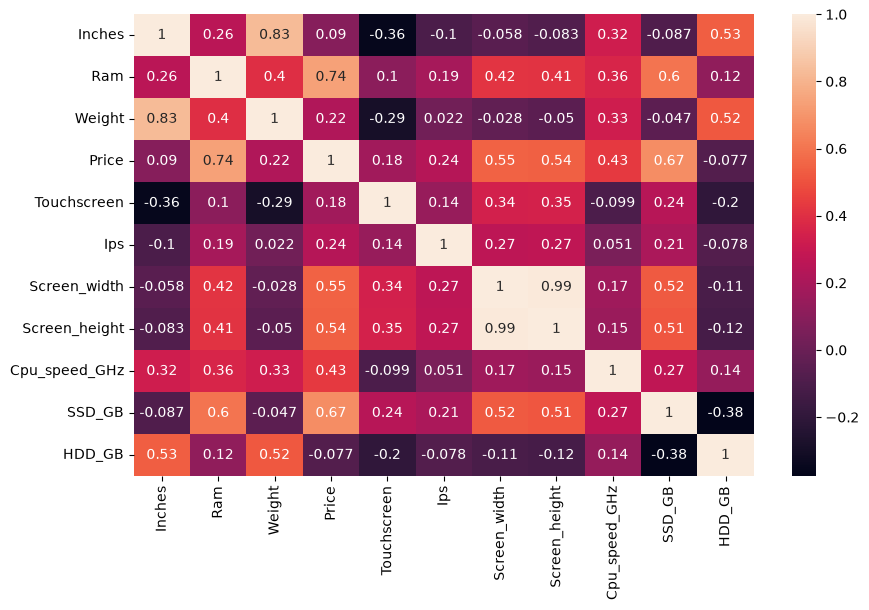

In [35]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [36]:
df.skew(numeric_only=True)

Inches          -0.388877
Ram              2.674166
Weight           1.162456
Price            1.481449
Touchscreen      1.902322
Ips              0.959523
Screen_width     2.194524
Screen_height    2.098592
Cpu_speed_GHz   -0.849684
SSD_GB           1.391213
HDD_GB           0.925808
dtype: float64

In [37]:
df.kurtosis(numeric_only=True)

Inches           -0.183217
Ram              15.095300
Weight            2.331843
Price             4.271238
Touchscreen       1.621512
Ips              -1.081109
Screen_width      6.255825
Screen_height     5.524509
Cpu_speed_GHz    -0.120040
SSD_GB            3.598919
HDD_GB           -0.020465
dtype: float64

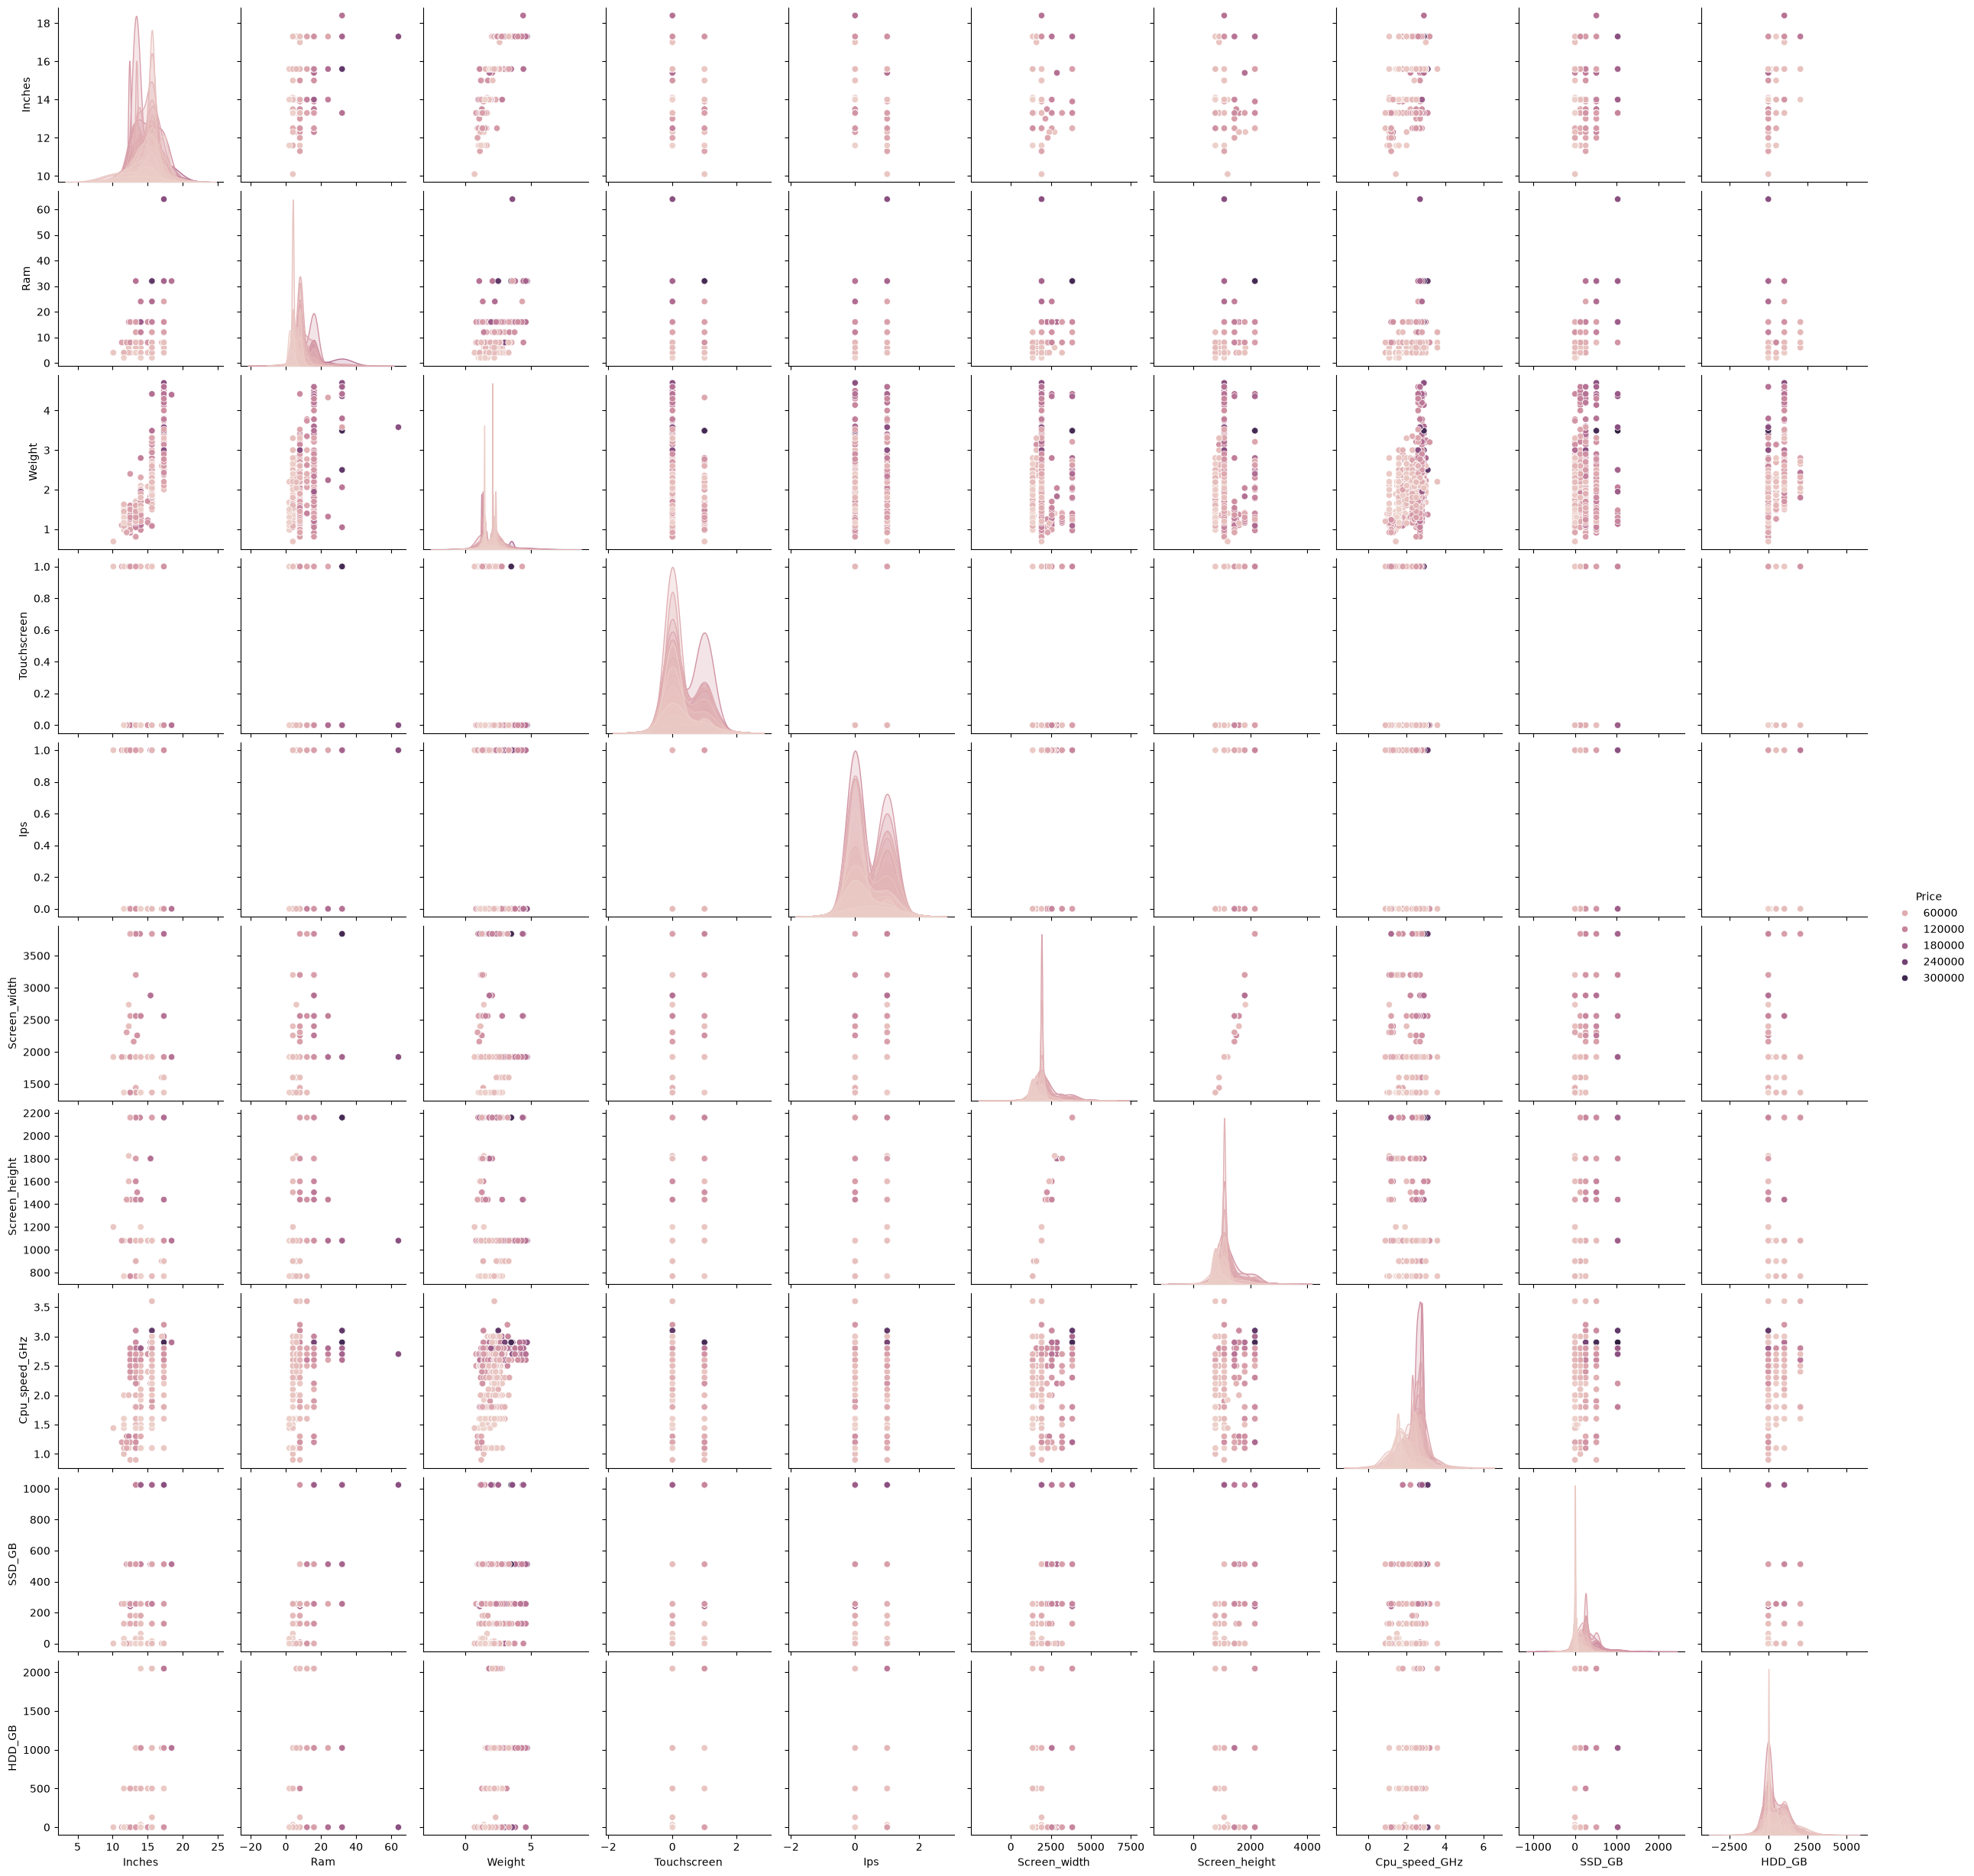

In [38]:
sns.pairplot(df,hue="Price")

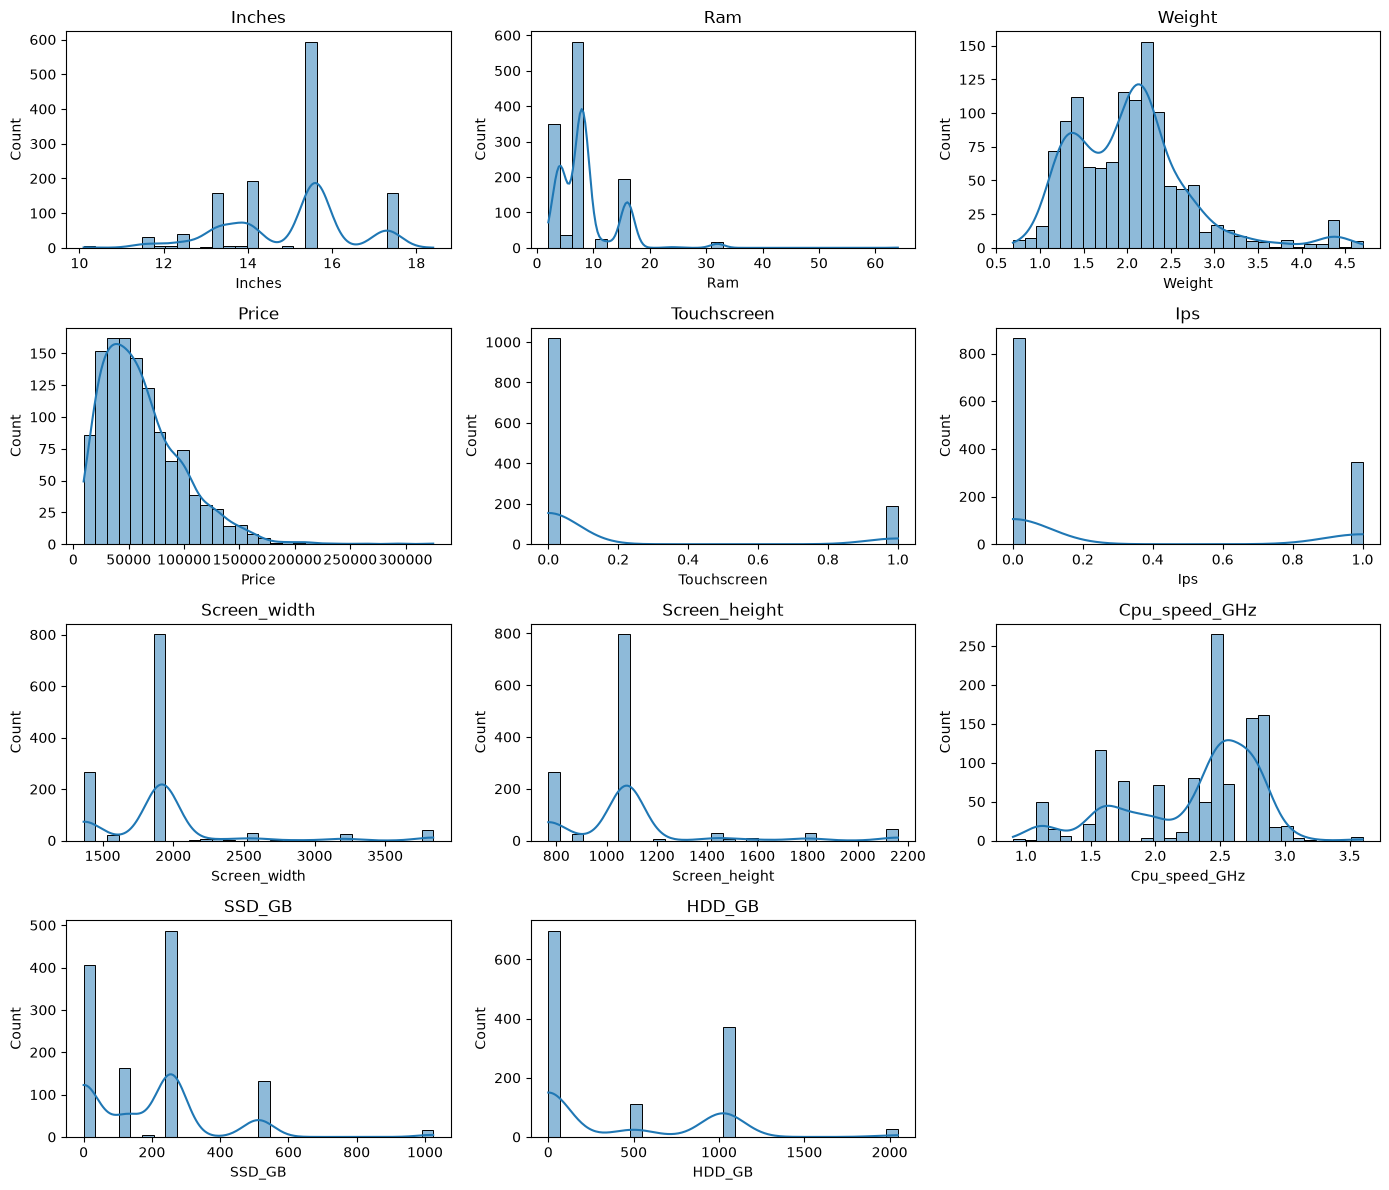

In [39]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(14, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)   # 4 rows, 3 columns
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

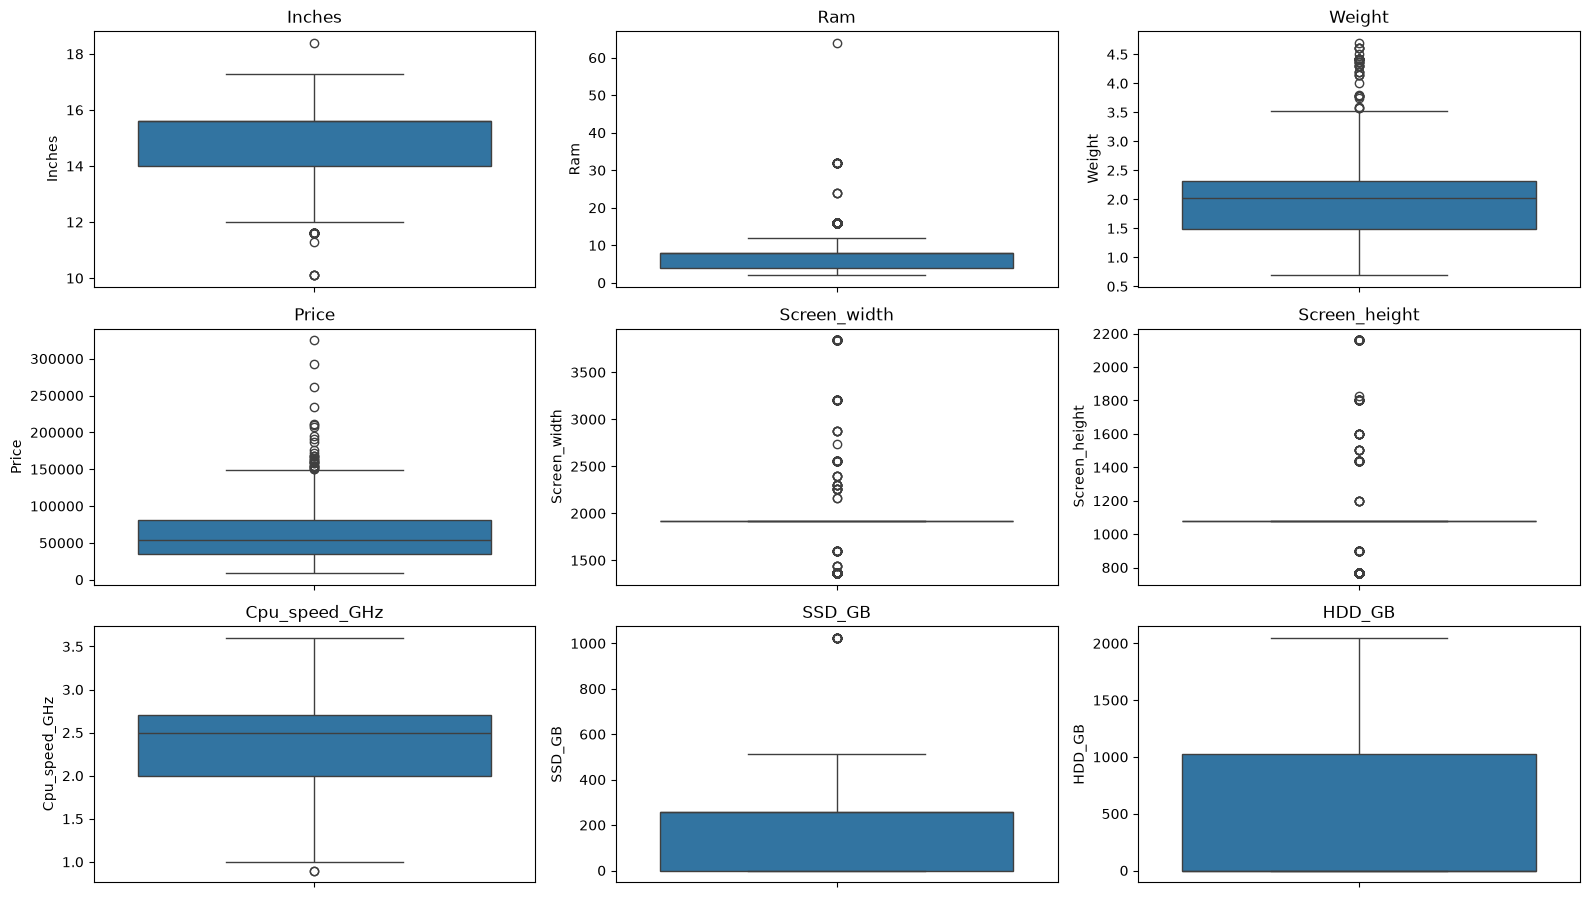

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns
num_cols = num_cols.drop(['Touchscreen', 'Ips'])

plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)      # Change 4,3 according to your number of columns
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

- **Target and Feature Selection**

In [41]:
x = df.drop(columns=['Price'])
y = df['Price']

- **Data Spliting**

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train = x_train.copy()
x_test = x_test.copy()

In [43]:
# Outliers Remove
num_cols = ['Inches', 'Ram', 'Weight', 'Cpu_speed_GHz']

for col in num_cols:
    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    x_train[col] = np.clip(x_train[col], lower, upper)
    x_test[col] = np.clip(x_test[col], lower, upper)

In [44]:
# Data Transformation (Log Transformation)
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

skewed_cols = ['Ram', 'SSD_GB', 'HDD_GB', 'Cpu_speed_GHz']

for col in skewed_cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])

In [45]:
# One-Hot Encoding
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

# Ensure no duplicate columns generated after OHE
x_train = x_train.loc[:, ~x_train.columns.duplicated()]
x_test = x_test.loc[:, ~x_test.columns.duplicated()]

encoded_col = list(x_train.columns)
joblib.dump(encoded_col, 'encoded_col.joblib')

# Safe Reindex
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [46]:
# Feature Scaling (StandardScaler)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [47]:
x_train.shape

(966, 49)

In [48]:
x_test.shape

(242, 49)

- **Model Training**

In [49]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8),
    "XGBoost Regressor": XGBRegressor(n_estimators=100, random_state=42)
}

print(f"{'Algorithm':<22} | {'Train R2':<10} | {'Test R2':<10} | {'Status'}")
print("---------------------------------------------------------------------")

for name, model in models.items():
    model.fit(x_train, y_train)
    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    diff = train_r2 - test_r2
    
    if train_r2 < 0.60 and test_r2 < 0.60:
        status = "Underfitting (High Bias)"
    elif diff > 0.10: 
        status = "Overfitting (High Variance)"
    else:
        status = "Good Fit / Optimal"
        
    print(f"{name:<22} | {train_r2:.4f}     | {test_r2:.4f}    | {status}")
    
print("---------------------------------------------------------------------")



Algorithm              | Train R2   | Test R2    | Status
---------------------------------------------------------------------
Linear Regression      | 0.8398     | 0.7979    | Good Fit / Optimal
Ridge Regression       | 0.8398     | 0.7981    | Good Fit / Optimal
Lasso Regression       | 0.8248     | 0.7883    | Good Fit / Optimal
Decision Tree          | 0.9981     | 0.7558    | Overfitting (High Variance)
Random Forest          | 0.9376     | 0.8510    | Good Fit / Optimal
XGBoost Regressor      | 0.9935     | 0.8821    | Overfitting (High Variance)
---------------------------------------------------------------------


In [50]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8)
rf.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [51]:
y_train_pred = rf.predict(x_train)
y_test_pred = rf.predict(x_test)

In [52]:
# Accuracy
train_r2 = r2_score(y_train, y_train_pred) * 100
test_r2 = r2_score(y_test, y_test_pred) * 100

In [53]:
print("Training R2 score: ", train_r2)
print("Testing R2 score: ", test_r2)

Training R2 score:  93.76151372546731
Testing R2 score:  85.09723053501261


- **Check Overfit & Underfit**

In [54]:
diff_rf = (train_r2 - test_r2)
diff_rf

8.664283190454697

In [55]:
# Model aur Scaler dono ko save karein
joblib.dump(rf, 'rf_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

# loaded_model = joblib.load('best_model.pkl')

['scaler.joblib']